In [33]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [34]:
package_folder = "/home/pablo.sanchez2/Documents/GitHub/project_spaice_ds/packages/pip/hakken_explainer"

asssets_folder = Path(os.path.join(package_folder, "assets"))
df_file = os.path.join(package_folder, "time_benchmark.tsv")
df = pd.read_csv(df_file, sep="\t")

df.head()

,triple,explanation_length,total_seconds,find_paths_seconds,num_paths
0,342e653c0fdcd883459ac1693797378c - [ASSOCIATE]...,4,5.122212,4.787910,1
1,735070c080b1154ef989be5dce730abe - [COTREAT] -...,4,5.673381,4.531198,634
2,3006378acea66ea4d14125a6cb22fb93 - [STIMULATE]...,3,5.536892,4.147197,110
3,c65bc237e314a9d8ef7fed7632e96cc5 - [ASSOCIATE]...,4,201.007210,5.340692,29264
4,2bed533b2358c861bf3d2ca09df2d2fe - [COTREAT] -...,3,5.409921,4.636958,6


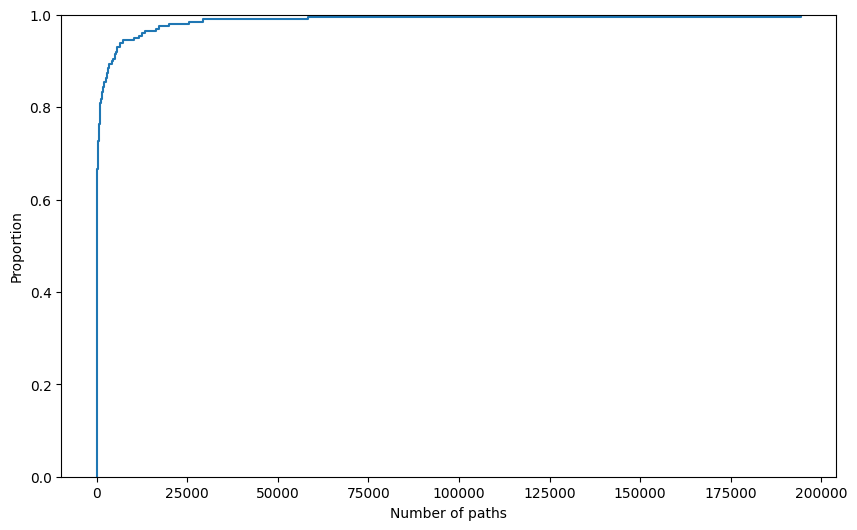

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.ecdfplot(data=df, x="num_paths", ax=ax)

ax.set_xlabel('Number of paths')

fig.savefig(asssets_folder / 'num_paths_ecdf.pdf', bbox_inches='tight')



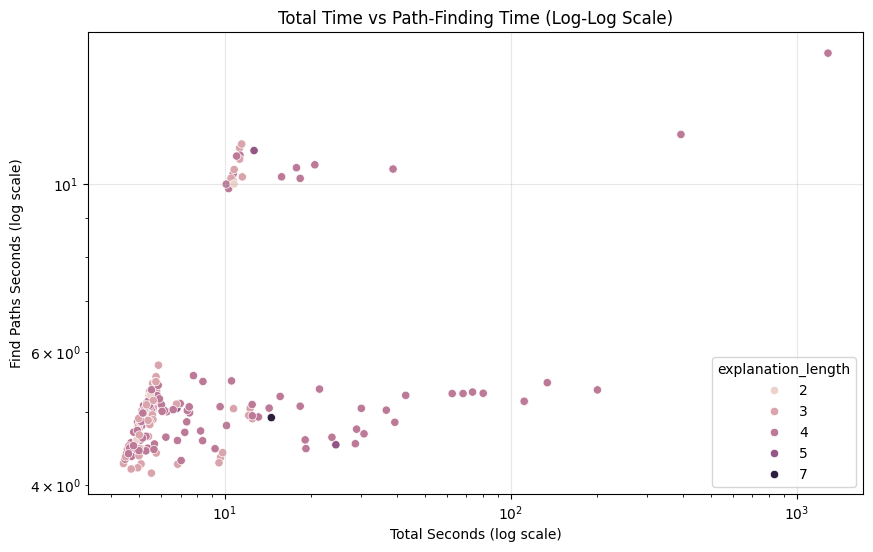

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="total_seconds", y="find_paths_seconds", hue="explanation_length",  ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total Seconds (log scale)')
ax.set_ylabel('Find Paths Seconds (log scale)')
ax.set_title('Total Time vs Path-Finding Time (Log-Log Scale)')
ax.grid(True, alpha=0.3)
fig.savefig(asssets_folder / 'time_scatterplot_1.pdf', bbox_inches='tight')
plt.show()

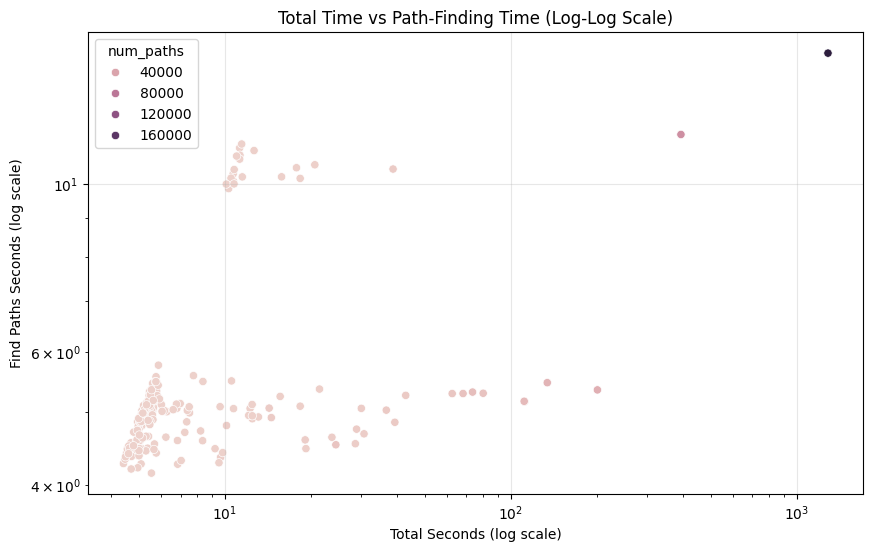

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="total_seconds", y="find_paths_seconds", hue="num_paths",  ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total Seconds (log scale)')
ax.set_ylabel('Find Paths Seconds (log scale)')
ax.set_title('Total Time vs Path-Finding Time (Log-Log Scale)')
ax.grid(True, alpha=0.3)
fig.savefig(asssets_folder / 'time_scatterplot_2.pdf', bbox_inches='tight')

plt.show()

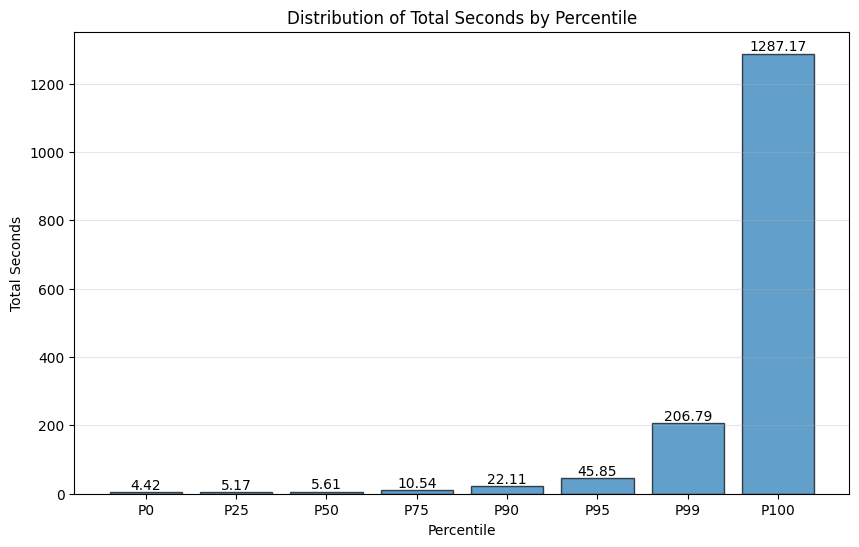

In [38]:
import numpy as np

# Calculate percentiles
percentiles = [0, 25, 50, 75, 90, 95, 99, 100]
percentile_values = np.percentile(df['total_seconds'], percentiles)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([f'P{p}' for p in percentiles], percentile_values, 
       edgecolor='black', alpha=0.7)
ax.set_xlabel('Percentile')
ax.set_ylabel('Total Seconds')
ax.set_title('Distribution of Total Seconds by Percentile')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on top of bars
for i, v in enumerate(percentile_values):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')


fig.savefig(asssets_folder / 'time_percentiles.pdf', bbox_inches='tight')

plt.show()